In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

loading data

In [4]:

train_data = np.load('fashion_train.npy')
test_data = np.load('fashion_test.npy')

X_train, y_train = train_data[:, :-1], train_data[:, -1]
X_test, y_test = test_data[:, :-1], test_data[:, -1]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(0.90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)



baseline svm

In [5]:

svc = SVC(kernel='rbf')
svc.fit(X_train_pca, y_train)

y_pred = svc.predict(X_test_pca)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Baseline Accuracy: 0.8482
              precision    recall  f1-score   support

           0       0.80      0.83      0.81      1000
           1       1.00      0.95      0.97      1000
           2       0.84      0.87      0.85      1000
           3       0.87      0.92      0.89      1000
           4       0.73      0.67      0.70      1000

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



finetuned svm

In [6]:

param_dist = {
    'C': np.logspace(0, 2, 6),  
    'gamma': np.logspace(-3, -2, 7),  
    'kernel': ['rbf']
}

randomized_search = RandomizedSearchCV(SVC(), param_distributions=param_dist, 
                                       n_iter=10, cv=2, verbose=2, scoring='accuracy', random_state=42)
randomized_search.fit(X_train_pca, y_train)


best_params = randomized_search.best_params_

# converting to float values
best_params['gamma'] = float(best_params['gamma'])
best_params['C'] = float(best_params['C'])
print(f"Best Parameters: {best_params}")

best_svc = randomized_search.best_estimator_
y_pred_tuned = best_svc.predict(X_test_pca)
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))


Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END C=15.848931924611142, gamma=0.004641588833612777, kernel=rbf; total time=   2.6s
[CV] END C=15.848931924611142, gamma=0.004641588833612777, kernel=rbf; total time=   2.6s
[CV] END .........C=2.51188643150958, gamma=0.01, kernel=rbf; total time=   3.7s
[CV] END .........C=2.51188643150958, gamma=0.01, kernel=rbf; total time=   3.6s
[CV] END C=2.51188643150958, gamma=0.0014677992676220691, kernel=rbf; total time=   1.7s
[CV] END C=2.51188643150958, gamma=0.0014677992676220691, kernel=rbf; total time=   1.7s
[CV] END C=15.848931924611142, gamma=0.006812920690579608, kernel=rbf; total time=   2.9s
[CV] END C=15.848931924611142, gamma=0.006812920690579608, kernel=rbf; total time=   2.9s
[CV] END ......C=1.0, gamma=0.004641588833612777, kernel=rbf; total time=   2.3s
[CV] END ......C=1.0, gamma=0.004641588833612777, kernel=rbf; total time=   2.3s
[CV] END ....C=100.0, gamma=0.004641588833612777, kernel=rbf; total time=   2

finding best values for parameters + imgs

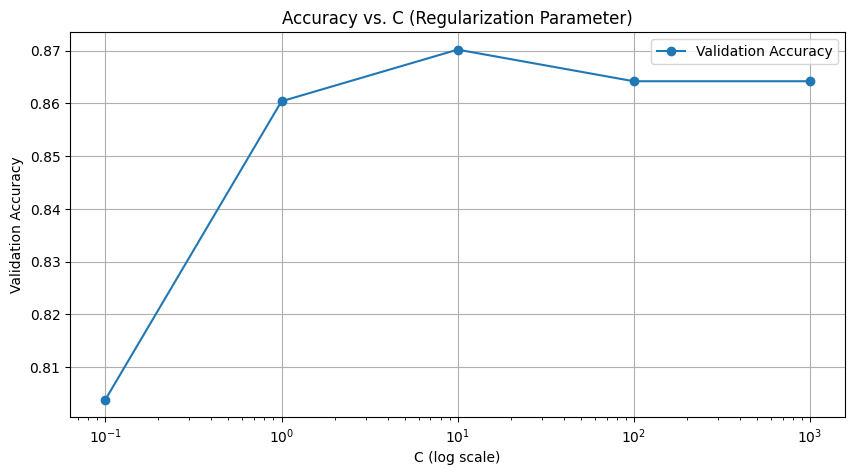

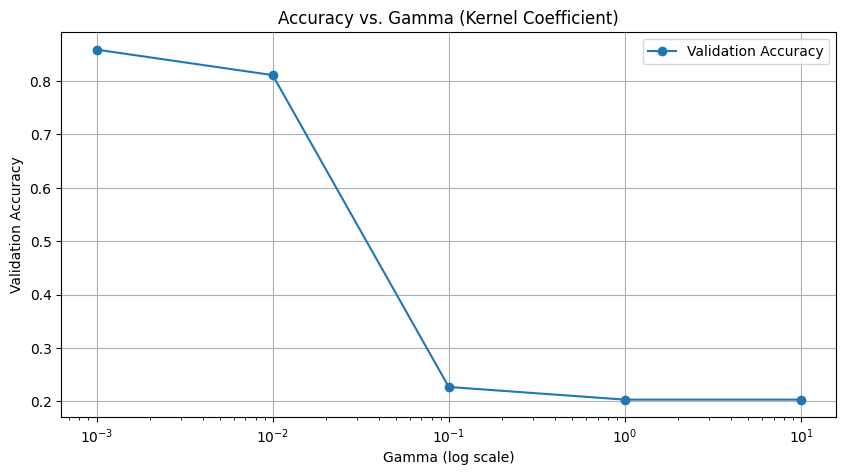

In [8]:

train_data = np.load('fashion_train.npy')
test_data = np.load('fashion_test.npy')
X_train, y_train = train_data[:, :-1], train_data[:, -1]
X_test, y_test = test_data[:, :-1], test_data[:, -1]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

C_values = [0.1, 1, 10, 100, 1000]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

# mean accuracy
C_accuracies = []
gamma_accuracies = []

for C in C_values:
    model = SVC(C=C, kernel='rbf', gamma='scale')
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    C_accuracies.append(scores.mean())

for gamma in gamma_values:
    model = SVC(C=1, kernel='rbf', gamma=gamma)  # Fixing C=1 for this plot
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    gamma_accuracies.append(scores.mean())

# Accuracy vs. C
plt.figure(figsize=(10, 5))
plt.plot(C_values, C_accuracies, marker='o', label="Validation Accuracy")
plt.xscale('log')
plt.title("Accuracy vs. C (Regularization Parameter)")
plt.xlabel("C (log scale)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.legend()

# Accuracy vs. Gamma
plt.figure(figsize=(10, 5))
plt.plot(gamma_values, gamma_accuracies, marker='o', label="Validation Accuracy")
plt.xscale('log')
plt.title("Accuracy vs. Gamma (Kernel Coefficient)")
plt.xlabel("Gamma (log scale)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.legend()
plt.show()